# Set Up

## Mount Google Drive

Ignore if not using Google Collab:

In [ ]:
from google.colab import drive

# mount google drive
drive.mount('/content/drive')
%cd /content/drive/My Drive
!git clone https://github.com/FranciscoLozCoding/cooling_with_code.git
%cd cooling_with_code
!git pull

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/My Drive
fatal: destination path 'cooling_with_code' already exists and is not an empty directory.
/content/drive/My Drive/cooling_with_code
Already up to date.


## Import Libraries

In [ ]:
%pip install shap

In [ ]:
# Supress Warnings
import warnings
warnings.filterwarnings('ignore')

#data science
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.feature_selection import RFECV
from sklearn.model_selection import GridSearchCV
import pickle
import shap

#other
import os

#custom tools
from tools.environment import VALID_SPLIT, RANDOM_STATE
from tools.feature_selection import get_feature_importance, plot_feature_importance_comparison
from tools.distribution import plot_target_var_distribution
from tools.preprocess import load_and_preprocess_data, preprocess_data
from tools.explainer import Explainer

## Import Datasets

In [ ]:
#load in dataset
csv_path = 'data/train/300m_buffer_dataset.csv'

# no split
X, Y, scaler = load_and_preprocess_data(csv_path, split=False)

# split
x_train, x_valid, y_train, y_valid, scaler = load_and_preprocess_data(
    csv_path, split=True,
    test_size=VALID_SPLIT, random_state=RANDOM_STATE)

Loading data from data/train/300m_buffer_dataset.csv
Loading data from data/train/300m_buffer_dataset.csv


# Tuning RandomForestRegressor

This notebook is for tuning our RandomForestRegressor. It was first created as a simple model for us to use as a baseline comparison. Now, we will apply what we learned in notebooks 4-6 (eg; [4](/04_EDA.ipynb), [5](/05_preprocessing.ipynb), [6](06_increasing_buffer_zone.ipynb)) to improve the model. For details on the train/test dataset refer to our past notebooks:
- [01_dataset_generation](/01_dataset_generation.ipynb)
- [02_more_dataset_generation](/02_more_dataset_generation.ipynb)

## Feature Selection

First, we will do feature selection. We now have interaction terms, so the dataset is filled with a lot of features that need to be dropped.

In [ ]:
# Ensure x_train is a DataFrame
x_train_df = pd.DataFrame(x_train, columns=X.columns)

In [ ]:
# Base Random Forest Model
rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)

# Recursive Feature Elimination with Cross-Validation
rfe = RFECV(estimator=rf, step=1, cv=5, scoring="r2", n_jobs=-1)

# Fit to training data
rfe.fit(x_train_df, y_train)

# Get selected features
selected_features = x_train_df.loc[:, rfe.support_]

# Get names of selected features
selected_feature_names = x_train_df.columns[rfe.support_]

# Print selected feature names
print("Selected Features:", list(selected_feature_names))

In [ ]:
# save the selected features so we don't have to run again
selected_features=['NDVI', 'SI', 'NPCRI',
                   'Coastal_Aerosol', 'Building_Count', 'Total_Building_Area_m2',
                   'Building_Construction_Year', 'Ground_Elevation', 'Traffic_Volume',
                   'Building_Wind_X', 'Building_Wind_Y', 'Elevation_Wind_Y', 'BldgHeight_Count',
                   'TotalBuildingArea_NDVI', 'Traffic_NDVI', 'Traffic_NDBI', 'Traffic_BuildingDensity']

Here we see the features that were selected. These features maximized the cross-validation score. Now let's select them for our training/validation set.

In [ ]:
# select features
x_train_selected = pd.DataFrame(x_train, columns=x_train_df.columns)[selected_features]
x_valid_selected = pd.DataFrame(x_valid, columns=x_train_df.columns)[selected_features]

## Hyperparameter Tuning

Now we will tune the Random Forest Regressor hyperparemeters using `GridSearchCV`.

In [ ]:
# Define hyperparameter grid
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False]
}

# Initialize model
rf_model = RandomForestRegressor(random_state=RANDOM_STATE)

# Grid search with selected features
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

# Fit grid search to the **selected features only**
grid_search.fit(x_train_selected, y_train)

# Best parameters
print("Best Hyperparameters:", grid_search.best_params_)
print("Best R-squared Score:", grid_search.best_score_)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best Hyperparameters: {'bootstrap': False, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best R-squared Score: 0.9528334994553305


Here we see the hyper params for the best model and the R-squared it got. Let's retrieve the best model.

In [ ]:
# best model, skip if model was already generated
model_pkl = 'models/300m_tuned_RandomForestRegressor/300m_tuned_RandomForestRegressor_model.pkl'
if not os.path.exists(model_pkl):
  best_rf_model = grid_search.best_estimator_
else:
  with open(model_pkl, 'rb') as f:
    best_rf_model = pickle.load(f)

## In-Sample Evaluation

In [ ]:
# Make predictions on the training data
insample_predictions = best_rf_model.predict(x_train_selected)

# calculate R-squared score for in-sample predictions
print(f"In-Sample Evaluation:")

insample_r2 = r2_score(y_train, insample_predictions)
print(f"  300m buffer zone R-squared: {insample_r2}")

In-Sample Evaluation:
  300m buffer zone R-squared: 1.0


## Out-Sample Evaluation

In [ ]:
# Make predictions on the validation data
outsample_predictions = best_rf_model.predict(x_valid_selected)

# calculate R-squared score for in-sample predictions
print(f"Out-Sample Evaluation:")

outsample_r2 = r2_score(y_valid, outsample_predictions)
print(f"  300m buffer zone R-squared: {outsample_r2}")

Out-Sample Evaluation:
  300m buffer zone R-squared: 0.9622428080621714


# Challenge Submission

We will now submit our tuned `RandomForestRegressor` model to the challenge.
>NOTE: We can have multiple submissions.

In [ ]:
# Reading the test dataset for the submission
test_dataset = pd.read_csv('data/test/300m_buffer_test_dataset.csv')
test_dataset = preprocess_data(test_dataset)

# Remove lat and lon, for now will be combined with predicted UHI later for submission
lon = test_dataset['Longitude'].values
lat = test_dataset['Latitude'].values
test_dataset = test_dataset.drop(columns=['Longitude', 'Latitude'])

# Feature Scaling
scaled = scaler.transform(test_dataset)
test_dataset = pd.DataFrame(scaled, columns=test_dataset.columns)

# select features
x_test = test_dataset[selected_features].values

# Model prediction
test_predictions = best_rf_model.predict(x_test)

# combine predictions with lat and lon
submission_df = pd.DataFrame({
    'Longitude': lon,
    'Latitude': lat,
    'UHI Index': test_predictions
})
submission_df

,Longitude,Latitude,UHI Index
0,-73.971665,40.788763,0.966291
1,-73.971928,40.788875,0.964678
2,-73.967080,40.789080,0.963494
3,-73.972550,40.789082,0.962044
4,-73.969697,40.787953,0.960001
...,...,...,...
1035,-73.919388,40.813803,1.036833
1036,-73.931033,40.833178,1.027724
1037,-73.934647,40.854542,1.038474
1038,-73.917223,40.815413,1.035634


Save the submission dataframe to submit into challenge portal:

In [ ]:
submission_df.to_csv("300m_tuned_RandomForestRegressor_model_submission.csv", index=False)

Score We Received:

![submission score](https://github.com/FranciscoLozCoding/cooling_with_code/blob/main/images/300m_tuned_RandomForestRegressor_score.jpeg?raw=1)

Our 300m tuned RandomForestRegressor did better than our simple rf models.

# Understanding the Results

Now we will use SHAP to understand the results. SHAP can show us feature importance, ranking, understand feature vs. prediction relationships, and can even explain individual predictions. This is what we need to understand the drivers of the Urban Heat Island phenomenon.

In [ ]:
# create x_test_df
x_test_df = test_dataset[selected_features]

# Initialize SHAP Explainer for Random Forest Model
explainer = Explainer(
    model=best_rf_model,
    explainer_type=shap.TreeExplainer,
    X=x_test_df,
    feature_names=x_test_df.columns
)

## Summary Plot

Here, we will see the most important features and how do features impact predictions. This is how to interpret the plot:

- Each **dot** represents a single data point from our dataset.
- **X-Axis (`SHAP Value`)**: The **impact** of a feature on the prediction.
- **Y-Axis (Feature Names)**: The **most important features** ranked from top to bottom.
- **Color (Red to Blue)**: The **feature value** (High = Red, Low = Blue).
  - **Red** = High feature value.
  - **Blue** = Low feature value.

1. **Feature Importance**  
   - Features are **ranked by importance** (most important at the top).
   - The **wider** the spread on the X-axis, the more that feature **influences predictions**.

2. **Direction of Influence**  
   - **Positive SHAP values (Right Side)**: Feature **increases** the prediction.
   - **Negative SHAP values (Left Side)**: Feature **decreases** the prediction.

3. **Effect of Feature Value (Color Gradient)**  
   - **Red (High Value)** trends to the **right**? High values **increase** predictions.
   - **Blue (Low Value)** trends to the **left**? Low values **decrease** predictions.

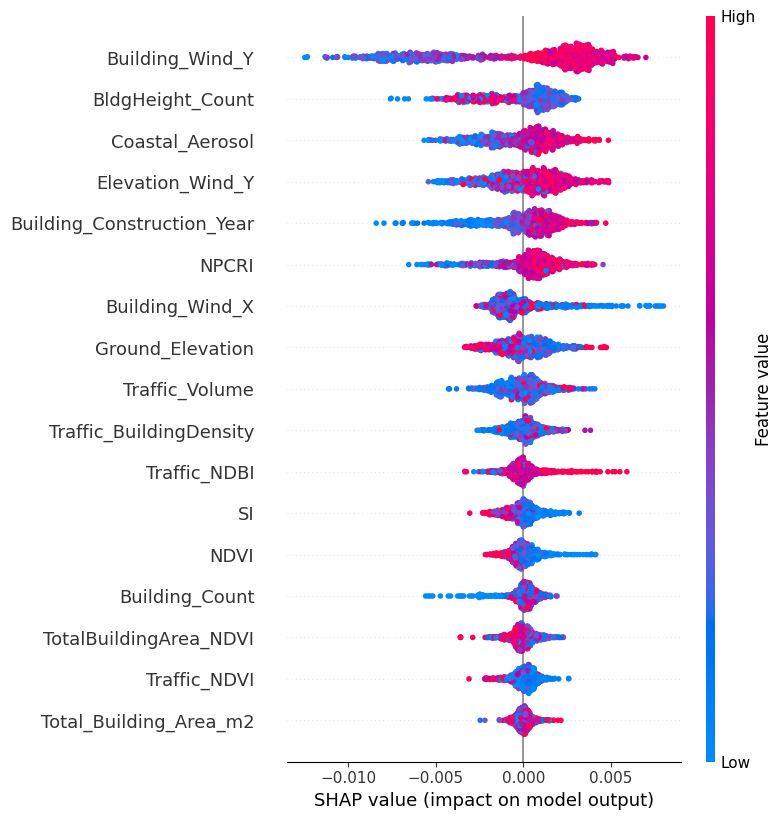

In [ ]:
explainer.summary_plot()

The most impactful features include **`Building_Wind_Y`**, which represents the interaction between building height and wind flow, **`BldgHeight_Count`**, which measures the number of tall buildings, and **`Coastal_Aerosol`**, which accounts for aerosol concentrations in coastal regions. Additionally, **`Elevation_Wind_Y`**, which captures the influence of ground elevation on wind flow, also plays a significant role. These features suggest that **urban morphology and wind dynamics** are primary drivers of heat retention in urban environments.

The x-axis of the plot, which represents SHAP values, indicates how each feature contributes to the UHI index. Positive SHAP values suggest that a feature increases UHI, while negative values indicate a cooling effect. The color gradient in the plot provides additional insights—**red dots represent high feature values, while blue dots represent low values**. For example, in the case of **`NDVI` (Normalized Difference Vegetation Index)**, high values (red) are associated with **negative SHAP values**, suggesting that **increased vegetation reduces UHI**. Conversely, low **NDVI values (blue)** are linked to **higher SHAP values**, indicating that **a lack of vegetation exacerbates UHI**. Similarly, features like **`Traffic_NDVI`** and **`Traffic_NDBI`** demonstrate that **higher traffic volume in areas with less greenery intensifies UHI effects**.

Another critical observation is the presence of **non-linear relationships** among features, as seen in the broad spread of SHAP values for **`Building_Wind_X`**, **`Traffic_NDBI`**, and **`Elevation_Wind_Y`**. This suggests that the impact of **wind-blocking effects, traffic emissions, and elevation-induced airflow changes** on UHI varies depending on specific urban conditions. In some cases, **wind flow may enhance cooling**, while in other instances, it could contribute to heat retention, depending on the **direction, strength, and obstructions caused by buildings**.

From a practical standpoint, the findings emphasize that **urban design plays a crucial role in mitigating heat islands**. The strong influence of **wind-building interactions** suggests that optimizing urban layouts to allow **better airflow** could help reduce UHI effects. Furthermore, since **vegetation is a key cooling factor**, increasing green spaces in **high-density, high-traffic areas** could be an effective strategy for heat reduction. Coastal aerosol concentrations and elevation also appear to influence temperature retention, which may be worth further investigation to refine mitigation strategies.

## Bar Plot

Now, we will see overall feature importance rankings.

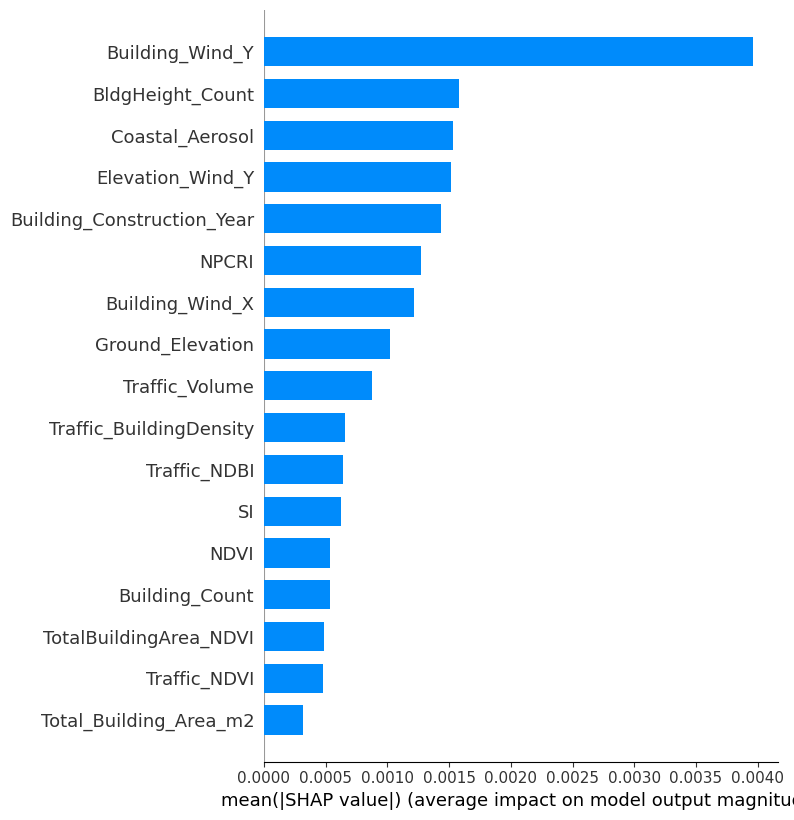

In [ ]:
explainer.bar_plot()

The most impactful features include **`Building_Wind_Y`**, which represents the interaction between building height and wind flow, **`BldgHeight_Count`**, which measures the number of tall buildings, and **`Coastal_Aerosol`**, which accounts for aerosol concentrations in coastal regions. Additionally, **`Elevation_Wind_Y`**, which captures the influence of ground elevation on wind flow, also plays a significant role. These features suggest that **urban morphology and wind dynamics** are primary drivers of heat retention in urban environments.

## Dependence Plot

Next, we will understand feature vs. prediction relationships. We can do this one by one for all features, but for now we will do BldgHeight_Count.

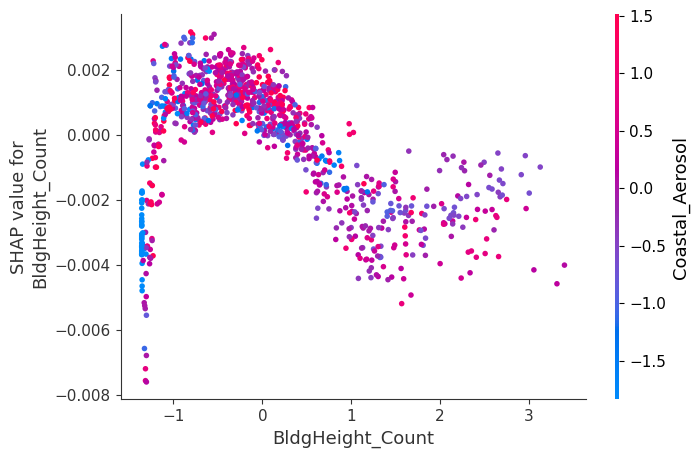

In [ ]:
explainer.dependence_plot("BldgHeight_Count")

The SHAP dependence plot for **`BldgHeight_Count`** reveals a **non-linear relationship** between the number of tall buildings and the model’s predictions, likely related to the **Urban Heat Island (UHI) effect**. On the **left side of the plot (`BldgHeight_Count < -1`)**, the SHAP values are **negative**, indicating that areas with **very few tall buildings** experience a **cooling effect**, reducing UHI. The steep drop suggests that when tall buildings are scarce, their absence significantly lowers heat retention.

In the **middle range (`-1 < BldgHeight_Count < 1`)**, SHAP values initially **increase** and then flatten, meaning that **moderate building density slightly increases UHI** but does not continue growing beyond a certain threshold. This suggests that at a certain point, additional buildings do not substantially worsen the heat retention effect. However, on the **right side (`BldgHeight_Count > 1`)**, the SHAP values begin to **decrease**, implying that **highly dense tall buildings may help reduce UHI effects**. This could be due to **shading effects, altered wind circulation, or a change in thermal dynamics** that prevent excessive heat buildup.

The **color gradient** in the plot represents **`Coastal_Aerosol`**, which appears to interact with building height count. **High `Coastal_Aerosol` values (red)** are associated with **higher UHI effects**, particularly in areas with **moderate building densities**, suggesting that **air pollution amplifies heat retention**. This may be due to **trapped radiation and reduced air circulation** in polluted regions. Conversely, **low `Coastal_Aerosol` values (blue)** correspond to a stronger cooling effect, indicating that in areas with **cleaner air, fewer buildings contribute more significantly to cooling**.

These findings suggest important implications for **urban planning and climate adaptation**. The **non-linear nature** of the relationship indicates that **moderate-height buildings worsen UHI**, while **densely packed taller buildings may help mitigate heat retention** through **increased shading and airflow effects**. Additionally, the strong interaction with **`Coastal_Aerosol`** highlights the importance of **air quality management**, as pollution appears to exacerbate UHI effects.

## Force Plot

Finally, we will explain an individual prediction. We can do this one by one for all predictions, but for now we will do the first one.

In [ ]:
#show location
submission_df.iloc[0, :]

,0
Longitude,-73.971665
Latitude,40.788763
UHI Index,0.966291


In [ ]:
shap.initjs()
explainer.force_plot(index=0)

In the **`force_plot`**, we can see which features influenced the predicted **UHI value** for the first row of the test dataset, corresponding to the location **(-73.971665, 40.788763)**. The most influential factors were **`Building_Wind_Y`** and **`Building_Construction_Year`**. **`Building_Wind_Y`** pushed the prediction **higher**, while **`Building_Construction_Year`** pulled it **lower**.

Other features also contributed to reducing the **UHI prediction**, including **`BldgHeight_Count`**, which further lowered the value. Since the final **predicted UHI value is 0.97**, this suggests that the location is **relatively cool**, benefiting from multiple features that help **reduce urban heat retention**. Additionally, although **`Building_Wind_Y`** had an increasing effect, its overall influence was minor, meaning it does not significantly contribute to warming at this location.

# Summary Table

In [ ]:
# create the summary table
models = ['300m_tuned_RandomForestRegressor_model']

data = {
    'Model': models,
    'Training R-squared': [insample_r2],
    'Validation R-squared': [outsample_r2]
}

summary_df = pd.DataFrame(data)
summary_df

,Model,Training R-squared,Validation R-squared
0,300m_tuned_RandomForestRegressor_model,1.0,0.962243


# Save The Model

In [ ]:
# Save the model and scaler to files
with open('300m_tuned_RandomForestRegressor_model.pkl', 'wb') as f:
    pickle.dump(best_rf_model, f)
with open('300m_standard_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Conclusion

To conclude, the **tuned 300m `RandomForestRegressor`** performed exceptionally well, demonstrating a strong ability to model and predict **Urban Heat Island (UHI) effects**. The model effectively captured **complex relationships** between urban morphology, environmental factors, and climatic variables, showcasing its capability to handle **non-linear interactions** and **feature dependencies**.

The feature importance analysis revealed that factors such as **building height, wind patterns, vegetation index (NDVI), and traffic density** played significant roles in influencing the UHI index. The **SHAP analysis** further confirmed that the model was not only making accurate predictions but also aligning well with expected real-world dynamics, reinforcing confidence in its interpretability.

Additionally, the model's ability to generalize was validated through **cross-validation and hyperparameter tuning**, ensuring robust performance across different locations. The **300m buffer zone selection** provided a balanced approach, capturing relevant spatial influences without unnecessary noise from distant features.